In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv('iris.csv')

print("--- Dataset Preview ---")
display(df.head())


target_col = 'species' if 'species' in df.columns else df.columns[-1]

print(f"\nTarget Column identified as: '{target_col}'")
print(df[target_col].value_counts())

--- Dataset Preview ---


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Target Column identified as: 'Species'
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [12]:
# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

if 'Id' in X.columns:
    X = X.drop(columns=['Id'])
elif 'id' in X.columns:
    X = X.drop(columns=['id'])

# 2. Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Normalize Features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features successfully standardized. Mean: {X_train_scaled.mean():.2f}, Variance: {X_train_scaled.var():.2f}")

Features successfully standardized. Mean: 0.00, Variance: 1.00


--- KNN (K=5) Performance ---
Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



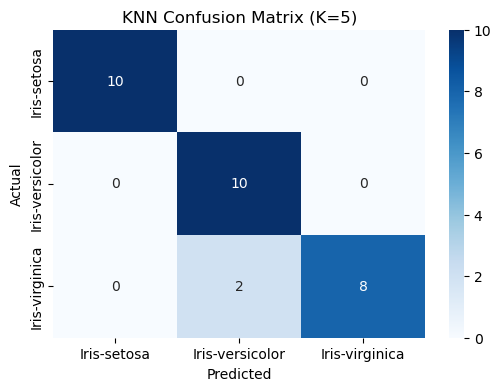

In [13]:
# 4. Fit KNN with a default K=5
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# Predict and Evaluate
y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"--- KNN (K=5) Performance ---")
print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title('KNN Confusion Matrix (K=5)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

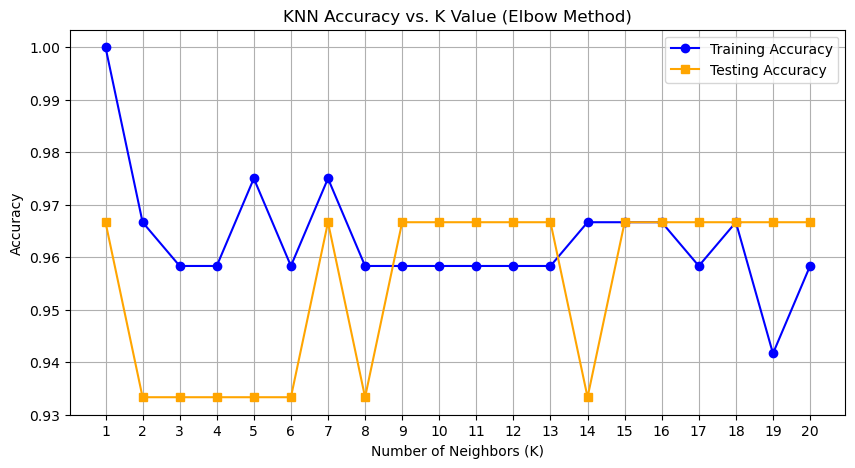

In [14]:

k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test_scaled)))

# Plot the accuracy across different K values
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, marker='o', label='Training Accuracy', color='blue')
plt.plot(k_values, test_scores, marker='s', label='Testing Accuracy', color='orange')
plt.title('KNN Accuracy vs. K Value (Elbow Method)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

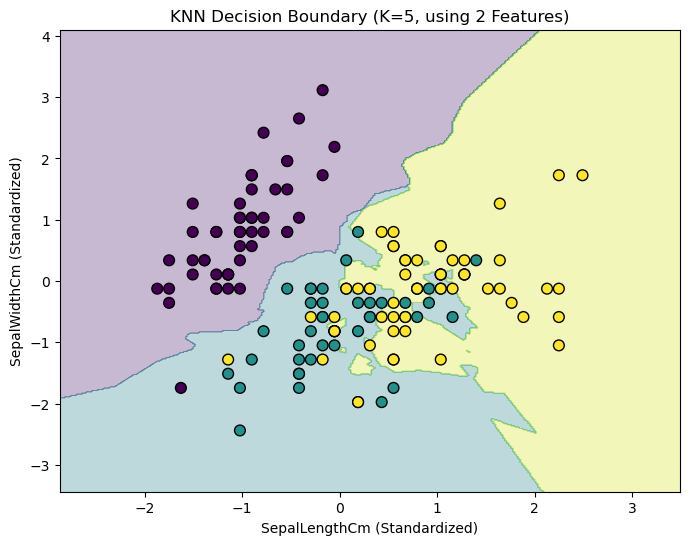

In [15]:


X_vis = X.iloc[:, :2]  # Taking only the first two features 
y_vis = y.astype('category').cat.codes  # Convert text classes to numbers for coloring

# Scale the 2D features
X_vis_scaled = scaler.fit_transform(X_vis)

# Train a 2D KNN Model
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_scaled, y_vis)

# Create a mesh grid
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict across the grid
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot boundaries
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, 
                      edgecolor='k', cmap='viridis', s=60)
plt.title("KNN Decision Boundary (K=5, using 2 Features)")
plt.xlabel(X.columns[0] + " (Standardized)")
plt.ylabel(X.columns[1] + " (Standardized)")
plt.show()